In [9]:
# ── Load results (handles both single-file and sharded output) ──────────────
import glob
import pandas as pd

OUTPUT_CSV = "./results/results_dp_sbm_dcsbm_n500.csv"

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

methods = sorted(df["method"].unique())

# Under degree correction the NOMINAL p,q are not what a plain-SBM estimator
# targets -- the empirical block densities are. Both are recorded; everything
# below compares against beta_true_* (empirical) and shows beta_nominal_* only
# as a reference line.
summary = (df.groupby("method")
             .agg(N=("N", "first"), K=("K", "first"),
                  n_sigmas=("sigma", "nunique"), n_reps=("rep", "nunique"),
                  rows=("nmi", "size")))
display(summary)

print(f"\nnominal   betas : within {df['beta_nominal_00'].iloc[0]:.4f}   "
      f"between {df['beta_nominal_01'].iloc[0]:.4f}")
print(f"empirical betas : within {df[['beta_true_00','beta_true_11']].mean().mean():.4f}   "
      f"between {df['beta_true_01'].mean():.4f}   "
      f"(ratio to nominal: {df['beta_true_00'].mean()/df['beta_nominal_00'].iloc[0]:.3f})")
df.head()

Loaded ./results/results_dp_sbm_dcsbm_n500.csv, 200 rows.


,N,K,n_sigmas,n_reps,rows
method,,,,,
edge_flip_vem,500,2,5,20,100
sbm_dpsgd_all_noised,500,2,5,20,100



nominal   betas : within 0.2000   between 0.0200
empirical betas : within 0.2003   between 0.0202   (ratio to nominal: 0.999)


,N,K,dc_sigma,normalize_weights,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,...,beta_nominal_00,beta_nominal_01,beta_nominal_11,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,500,2,0.25,True,0.5,75.261074,0,edge_flip_vem,NaN,NaN,...,0.2,0.02,0.2,0.198458,0.019616,0.202345,0.198458,0.019616,0.202345,1.000000
1,500,2,0.25,True,0.5,75.261074,0,sbm_dpsgd_all_noised,70.772185,12.423129,...,0.2,0.02,0.2,0.198458,0.019616,0.202345,0.175809,0.118818,0.150147,0.002994
2,500,2,0.25,True,0.5,75.261074,1,edge_flip_vem,NaN,NaN,...,0.2,0.02,0.2,0.198169,0.019552,0.200739,0.200739,0.019552,0.198169,1.000000
3,500,2,0.25,True,0.5,75.261074,1,sbm_dpsgd_all_noised,70.772185,12.423129,...,0.2,0.02,0.2,0.198169,0.019552,0.200739,0.225615,0.011750,0.214631,1.000000
4,500,2,0.25,True,0.5,75.261074,2,edge_flip_vem,NaN,NaN,...,0.2,0.02,0.2,0.200353,0.020032,0.199165,0.199165,0.020032,0.200353,1.000000


,rep,N,mean_degree,degree_cv,max_degree,min_degree,weight_mean,weight_cv,lcc_size,lcc_frac,n_components,n_isolated,beta_true_00,beta_true_01,beta_true_11
mean,9.5000,500.0,54.9126,0.2253,102.8000,28.950,1.0,0.1902,500.0,1.0,1.0,0.0,0.1999,0.0202,0.2007
std,5.9161,0.0,0.3682,0.0063,6.6854,1.905,0.0,0.0061,0.0,0.0,0.0,0.0,0.0035,0.0005,0.0032
min,0.0000,500.0,54.1200,0.2120,93.0000,25.000,1.0,0.1799,500.0,1.0,1.0,0.0,0.1910,0.0192,0.1966
max,19.0000,500.0,55.6400,0.2395,120.0000,32.000,1.0,0.2010,500.0,1.0,1.0,0.0,0.2060,0.0213,0.2088


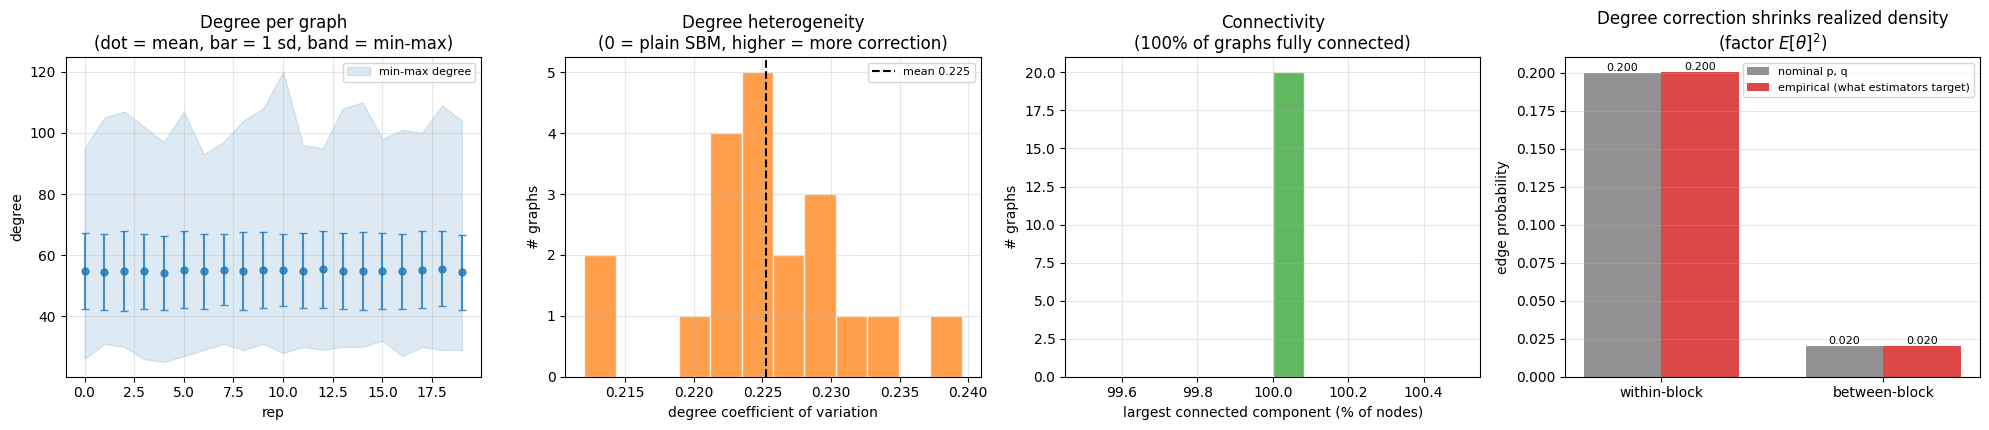

In [10]:
# ── Summary of the generated DC-SBM graphs ─────────────────────────────────
# Dedup note: the rep seed depends on rep only, NOT on sigma, so the same
# graph is reused across every sigma and both methods. Without the
# drop_duplicates each graph would be counted 2*len(SIGMAS) times.
import numpy as np
import matplotlib.pyplot as plt

graphs = df.drop_duplicates(subset=["rep"])[
    ["rep", "N", "mean_degree", "degree_cv", "max_degree", "min_degree",
     "weight_mean", "weight_cv", "lcc_size", "lcc_frac", "n_components",
     "n_isolated", "beta_true_00", "beta_true_01", "beta_true_11"]
].copy()

display(graphs.describe().loc[["mean", "std", "min", "max"]].round(4))

colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 4, figsize=(20, 4.4))

# (a) degree level and spread
ax = axes[0]
ax.errorbar(graphs["rep"], graphs["mean_degree"],
            yerr=graphs["mean_degree"] * graphs["degree_cv"],
            fmt="o", color=colors[0], alpha=0.8, capsize=3, markersize=5)
ax.fill_between(graphs["rep"], graphs["min_degree"], graphs["max_degree"],
                color=colors[0], alpha=0.15, label="min-max degree")
ax.set_xlabel("rep"); ax.set_ylabel("degree")
ax.set_title("Degree per graph\n(dot = mean, bar = 1 sd, band = min-max)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

# (b) degree heterogeneity -- the whole point of degree correction
ax = axes[1]
ax.hist(graphs["degree_cv"], bins=12, color=colors[1], alpha=0.75, edgecolor="white")
ax.axvline(graphs["degree_cv"].mean(), color="black", linestyle="--",
           label=f"mean {graphs['degree_cv'].mean():.3f}")
ax.set_xlabel("degree coefficient of variation"); ax.set_ylabel("# graphs")
ax.set_title("Degree heterogeneity\n(0 = plain SBM, higher = more correction)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

# (c) connectivity -- dense here, so this should be a degenerate 100% bar
ax = axes[2]
ax.hist(graphs["lcc_frac"] * 100, bins=12, color=colors[2], alpha=0.75, edgecolor="white")
ax.set_xlabel("largest connected component (% of nodes)"); ax.set_ylabel("# graphs")
ax.set_title(f"Connectivity\n({(graphs['lcc_frac'] == 1.0).mean():.0%} of graphs fully connected)")
ax.grid(alpha=0.3)

# (d) empirical vs nominal block densities
ax = axes[3]
x = np.arange(2); w = 0.35
emp = [graphs[["beta_true_00", "beta_true_11"]].mean().mean(), graphs["beta_true_01"].mean()]
nom = [df["beta_nominal_00"].iloc[0], df["beta_nominal_01"].iloc[0]]
ax.bar(x - w/2, nom, w, label="nominal p, q", color=colors[7], alpha=0.85)
ax.bar(x + w/2, emp, w, label="empirical (what estimators target)",
       color=colors[3], alpha=0.85)
for xi, (a, b) in enumerate(zip(nom, emp)):
    ax.text(xi - w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi + w/2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["within-block", "between-block"])
ax.set_ylabel("edge probability")
ax.set_title("Degree correction shrinks realized density\n(factor $E[\\theta]^2$)")
ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

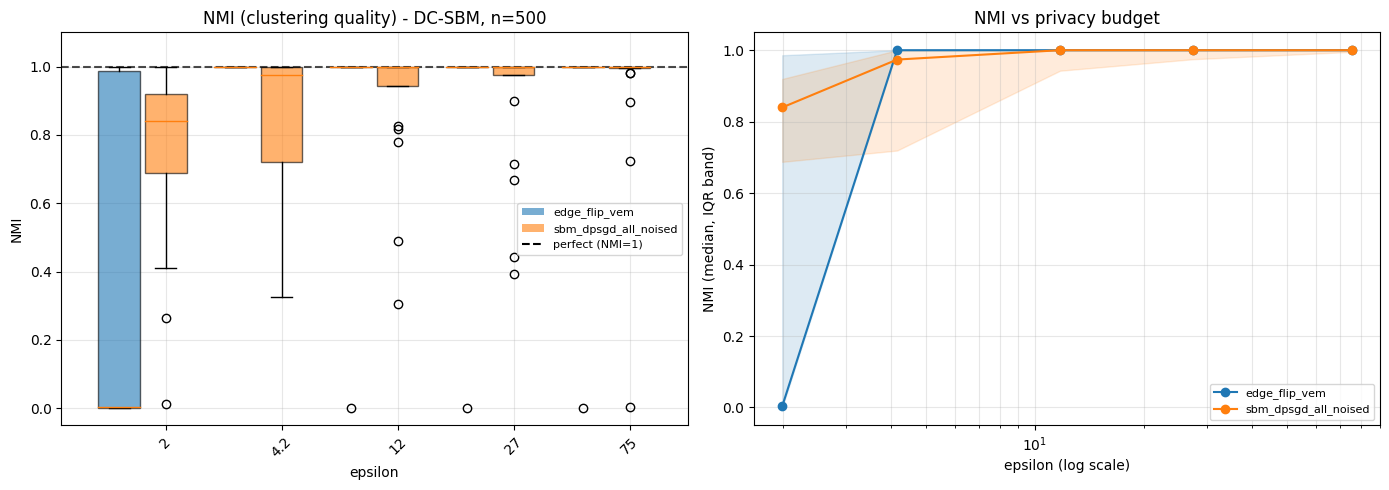

In [11]:
# ── NMI vs epsilon ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

colors = plt.cm.tab10.colors
eps_vals = sorted(df["epsilon"].unique())
width = 0.8 / len(methods)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) boxplots per epsilon
ax = axes[0]
data, positions = [], []
for e_idx, eps in enumerate(eps_vals):
    for m_idx, method in enumerate(methods):
        vals = df[(df["epsilon"] == eps) & (df["method"] == method)]["nmi"].dropna()
        if len(vals) == 0:
            continue
        data.append(vals.values)
        positions.append(e_idx + (m_idx - len(methods) / 2) * width)
bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors[(i % len(methods)) % len(colors)])
    patch.set_alpha(0.6)
ax.axhline(1.0, color="black", linestyle="--", alpha=0.7, linewidth=1.5)
ax.set_ylim(-0.05, 1.1)
ax.set_xticks(range(len(eps_vals)))
ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
ax.set_xlabel("epsilon"); ax.set_ylabel("NMI")
ax.set_title("NMI (clustering quality) - DC-SBM, n=500")
ax.grid(alpha=0.3)
legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m)
                for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="perfect (NMI=1)"))
ax.legend(handles=legend_elems, fontsize=8)

# (b) median trend with IQR band
ax = axes[1]
for m_idx, method in enumerate(methods):
    sub = df[df["method"] == method]
    g = sub.groupby("epsilon")["nmi"]
    ev = sorted(g.groups.keys())
    med = [g.get_group(e).median() for e in ev]
    q1 = [g.get_group(e).quantile(0.25) for e in ev]
    q3 = [g.get_group(e).quantile(0.75) for e in ev]
    ax.plot(ev, med, marker="o", color=colors[m_idx % len(colors)], label=method)
    ax.fill_between(ev, q1, q3, color=colors[m_idx % len(colors)], alpha=0.15)
ax.set_xscale("log")
ax.set_xlabel("epsilon (log scale)"); ax.set_ylabel("NMI (median, IQR band)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("NMI vs privacy budget")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

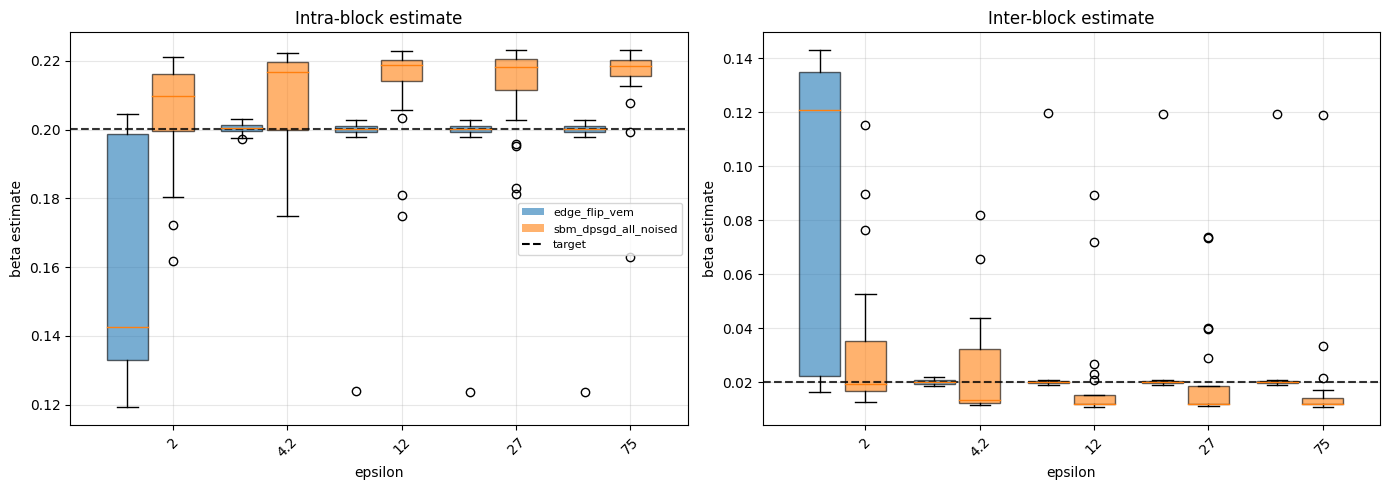

In [12]:
# ── Estimated beta vs epsilon ──────────────────────────────────────────────
# Black line = target block density. With NORMALIZE_WEIGHTS=True (E[theta]=1)
# the empirical density and the nominal p,q coincide, so a single target line
# suffices -- it is what a plain-SBM estimator aims at.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

colors = plt.cm.tab10.colors
eps_vals = sorted(df["epsilon"].unique())
width = 0.8 / len(methods)

est = df.copy()
est["intra_est"] = est[["beta_est_00", "beta_est_11"]].mean(axis=1)
est["intra_true"] = est[["beta_true_00", "beta_true_11"]].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (est_col, true_col, title) in zip(axes, [
    ("intra_est", "intra_true", "Intra-block estimate"),
    ("beta_est_01", "beta_true_01", "Inter-block estimate"),
]):
    data, positions = [], []
    for e_idx, eps in enumerate(eps_vals):
        for m_idx, method in enumerate(methods):
            vals = est[(est["epsilon"] == eps) & (est["method"] == method)][est_col].dropna()
            if len(vals) == 0:
                continue
            data.append(vals.values)
            positions.append(e_idx + (m_idx - len(methods) / 2) * width)
    bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(colors[(i % len(methods)) % len(colors)])
        patch.set_alpha(0.6)
    ax.axhline(est[true_col].mean(), color="black", linestyle="--", linewidth=1.5,
               alpha=0.8, label="target")
    ax.set_xticks(range(len(eps_vals)))
    ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
    ax.set_xlabel("epsilon"); ax.set_ylabel("beta estimate")
    ax.set_title(title)
    ax.grid(alpha=0.3)

legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m)
                for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="target"))
axes[0].legend(handles=legend_elems, fontsize=8)
plt.tight_layout()
plt.show()

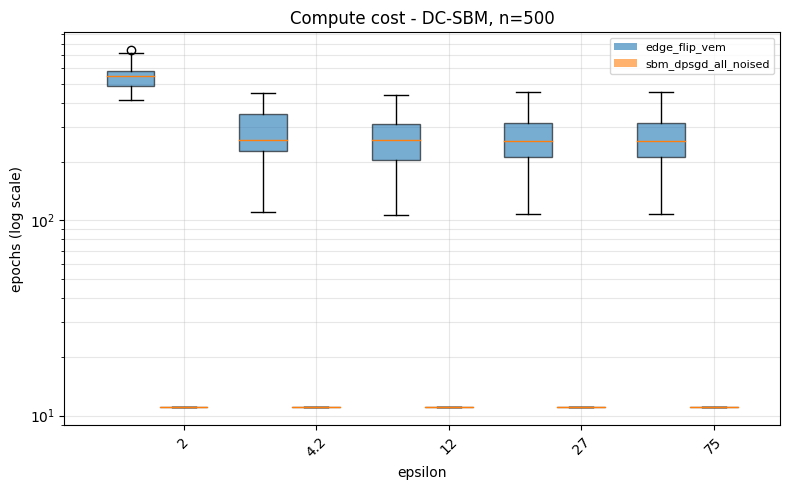

In [14]:
# ── Compute cost (epochs) vs epsilon ───────────────────────────────────────
# Log scale: the two methods differ by ~1-2 orders of magnitude.
# CAVEAT: an epoch is NOT wall-clock comparable across methods -- a VEM epoch
# is a dense O(N^2) matmul pass, an SBM-DPSGD epoch is a sampled
# per-example-autodiff pass.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

colors = plt.cm.tab10.colors
eps_vals = sorted(df["epsilon"].unique())
width = 0.8 / len(methods)

fig, ax = plt.subplots(figsize=(8, 5))
data, positions = [], []
for e_idx, eps in enumerate(eps_vals):
    for m_idx, method in enumerate(methods):
        vals = df[(df["epsilon"] == eps) & (df["method"] == method)]["epochs"].dropna()
        if len(vals) == 0:
            continue
        data.append(vals.values)
        positions.append(e_idx + (m_idx - len(methods) / 2) * width)
bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors[(i % len(methods)) % len(colors)])
    patch.set_alpha(0.6)
ax.set_yscale("log")
ax.set_xticks(range(len(eps_vals)))
ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
ax.set_xlabel("epsilon"); ax.set_ylabel("epochs (log scale)")
ax.set_title("Compute cost - DC-SBM, n=500")
ax.grid(alpha=0.3, which="both")
ax.legend(handles=[Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m)
                   for i, m in enumerate(methods)], fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# ── Summary table ──────────────────────────────────────────────────────────
import pandas as pd

tbl = df.copy()
tbl["intra_est"] = tbl[["beta_est_00", "beta_est_11"]].mean(axis=1)
tbl["intra_true"] = tbl[["beta_true_00", "beta_true_11"]].mean(axis=1)
tbl["rel_intra"] = (tbl["intra_est"] - tbl["intra_true"]).abs() / tbl["intra_true"]
tbl["rel_inter"] = (tbl["beta_est_01"] - tbl["beta_true_01"]).abs() / tbl["beta_true_01"]

out = (tbl.groupby(["sigma", "epsilon", "method"])
          .agg(nmi_median=("nmi", "median"),
               nmi_iqr=("nmi", lambda s: s.quantile(0.75) - s.quantile(0.25)),
               intra_est_median=("intra_est", "median"),
               inter_est_median=("beta_est_01", "median"),
               rel_intra_median=("rel_intra", "median"),
               rel_inter_median=("rel_inter", "median"),
               epochs_median=("epochs", "median"),
               n=("nmi", "size"))
          .round(4).reset_index().sort_values(["sigma", "method"]))
display(out)

,sigma,epsilon,method,nmi_median,nmi_iqr,intra_est_median,inter_est_median,rel_intra_median,rel_inter_median,epochs_median,n
0,0.5,75.261074,edge_flip_vem,1.0000,0.0000,0.2002,0.0203,0.0000,0.0000,256.0,20
1,0.5,75.261074,sbm_dpsgd_all_noised,1.0000,0.0047,0.2184,0.0121,0.0930,0.3973,11.0,20
2,1.0,27.449963,edge_flip_vem,1.0000,0.0000,0.2002,0.0203,0.0000,0.0000,256.0,20
3,1.0,27.449963,sbm_dpsgd_all_noised,1.0000,0.0252,0.2183,0.0121,0.0941,0.4094,11.0,20
4,2.0,11.732852,edge_flip_vem,1.0000,0.0000,0.2003,0.0203,0.0000,0.0004,259.0,20
5,2.0,11.732852,sbm_dpsgd_all_noised,1.0000,0.0574,0.2187,0.0122,0.0945,0.4022,11.0,20
6,5.0,4.150006,edge_flip_vem,1.0000,0.0000,0.2005,0.0203,0.0017,0.0242,259.0,20
7,5.0,4.150006,sbm_dpsgd_all_noised,0.9738,0.2808,0.2168,0.0134,0.0885,0.3870,11.0,20
8,10.0,1.995318,edge_flip_vem,0.0037,0.9856,0.1427,0.1208,0.2838,4.9050,547.0,20
9,10.0,1.995318,sbm_dpsgd_all_noised,0.8398,0.2319,0.2098,0.0193,0.0706,0.3200,11.0,20
